# **Dynamic Fan-Out (Map Reduce) In LangGraph**

In [1]:
from langchain_core.messages import HumanMessage;
from typing import TypedDict, Annotated;
from langchain_groq import ChatGroq;
from pydantic import BaseModel;
from dotenv import load_dotenv;
import operator;

load_dotenv();

llm = ChatGroq(model="llama-3.3-70b-versatile");

class OverallState(TypedDict):
    topic: str;
    subtopics: list[str];
    summaries: Annotated[list[dict], operator.add];
    final_report: str;

class WorkerState(TypedDict):
    subtopic: str;
    summaries: Annotated[list[dict], operator.add];

class ListTopics(BaseModel):
    topics: list[str];

llm_structured = llm.with_structured_output(ListTopics);

In [2]:
def plan_node(state: OverallState) -> dict:

    response: ListTopics = llm_structured.invoke(
        [HumanMessage(f"Provide 5 topics of the given topic: {state["topic"]}.")]
    );

    subtopics = response.topics;

    print(f"[plan] {len(subtopics)} subtopics → parallel workers");

    return {"subtopics": subtopics};

def research_worker(state: WorkerState) -> dict:

    summary = {
        "subtopic": state["subtopic"],
        "content": f"[Content for: {state["subtopic"]}]"
    };

    print(f" [worker] Done: {state["subtopic"]}");

    return {"summaries": [summary]};

def compile_report(state: OverallState) -> dict:

    report = f"📋 REPORT: {state["topic"]}\n" + "\n".join(
        f"  [{i+1}] {s["subtopic"]} {s["content"]}" for i, s in enumerate(state["summaries"])
    );

    return {"final_report": report};

In [3]:
from langgraph.types import Send;

def fan_out(state: OverallState):
    
    return [ # Send Each Subtopic To Its Own Worker In Parallel
        Send(
            "worker",
            {
                "subtopic": t,
                "summaries": []
            }
        )
        for t in state["subtopics"]
    ];

In [4]:
from langgraph.graph import StateGraph, START, END;

builder = StateGraph(OverallState);

builder.add_node("plan", plan_node);

builder.add_node("worker", research_worker);

builder.add_node("compile", compile_report);

builder.add_edge(START, "plan");

builder.add_conditional_edges("plan", fan_out, ["worker"]);

builder.add_edge("worker", "compile");

builder.add_edge("compile", END);

graph = builder.compile();

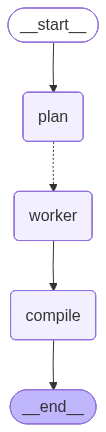

In [5]:
from IPython.display import Image, display;

display(Image(graph.get_graph().draw_mermaid_png())); # Dotted Line Present Subtopic Parallel Execution

In [6]:
result = graph.invoke(
    {
        "topic": "LangGraph",
        "subtopics": [],
        "summaries": [],
        "final_report": ""
    }
);

print("\n" + result["final_report"]);

[plan] 5 subtopics → parallel workers
 [worker] Done: Introduction to LangGraph
 [worker] Done: LangGraph Architecture
 [worker] Done: LangGraph Applications
 [worker] Done: LangGraph vs Other Models
 [worker] Done: Training LangGraph

📋 REPORT: LangGraph
  [1] Introduction to LangGraph [Content for: Introduction to LangGraph]
  [2] LangGraph Architecture [Content for: LangGraph Architecture]
  [3] LangGraph Applications [Content for: LangGraph Applications]
  [4] LangGraph vs Other Models [Content for: LangGraph vs Other Models]
  [5] Training LangGraph [Content for: Training LangGraph]
